In [1]:
#### install and load packages needed for graphing #############################

# install.packages("tidyverse")
# install.packages("cowplot")

library(tidyverse)
library(cowplot)

stage_colors <- c(immature = "#93C572", mature = "#3F7A43")
outline      <- "grey25"

theme_set(theme_cowplot(font_size = 12))
options(repr.plot.width = 8, repr.plot.height = 4.5)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
#### read in data ##############################################################

cells <- read_csv("data/cell_areas.csv", show_col_types = FALSE)

cells$stage <- factor(cells$stage, levels = c("immature", "mature"))

cells %>% count(stage, zone, image, use)

stage,zone,image,use,n
<fct>,<chr>,<chr>,<lgl>,<int>
immature,throat,ithftrichome2_800x,TRUE,6
immature,throat,ithftrichome800x,TRUE,7
mature,stomach,msf800x,FALSE,10
mature,throat,mthf,TRUE,9


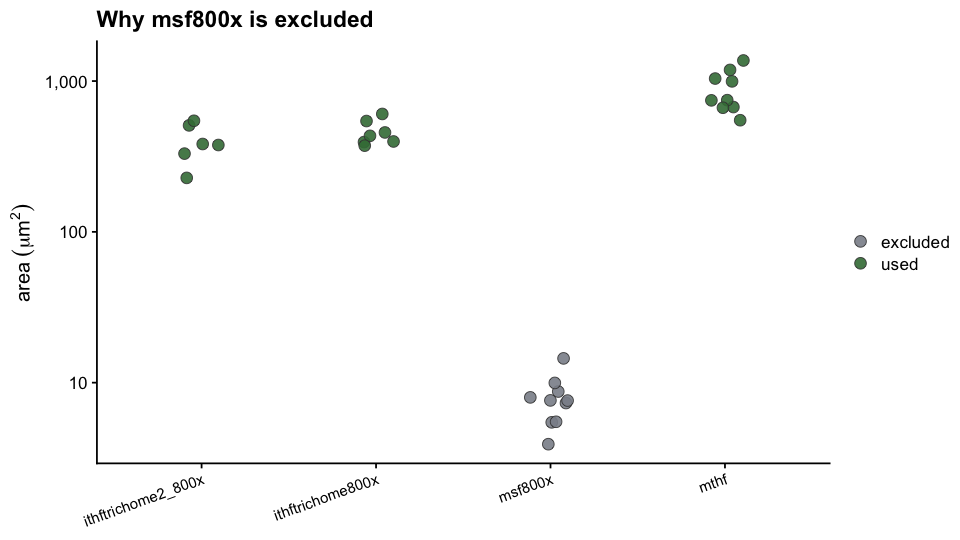

In [3]:
#### plot showing why msf800x is left out ######################################

# its areas imply a 3 µm cell; real epidermal cells are 25-30 µm

plot0 <- ggplot(cells, aes(x = image, y = area_um2, fill = use)) +
  geom_jitter(shape = 21, width = 0.12, size = 3, stroke = 0.4,
              colour = outline, alpha = 0.9) +
  scale_y_log10(labels = scales::comma) +
  scale_fill_manual(values = c(`TRUE` = "#3F7A43", `FALSE` = "#8A8F98"),
                    labels = c(`TRUE` = "used", `FALSE` = "excluded")) +
  labs(title = "Why msf800x is excluded", x = NULL,
       y = expression(area~(mu*m^2)), fill = NULL) +
  theme(axis.text.x = element_text(angle = 20, hjust = 1, size = 9))

plot0
ggsave("output/cell_area_excluded.png", plot0, width = 8, height = 4.5, dpi = 300)

In [4]:
#### create objects that filter out specific measurements ######################

cells %>%
  filter(use == TRUE) -> good_cells

good_cells %>%
  mutate(diameter_um = 2 * sqrt(area_um2 / pi)) -> good_cells

good_cells

stage,zone,image,area_um2,use,diameter_um
<fct>,<chr>,<chr>,<dbl>,<lgl>,<dbl>
immature,throat,ithftrichome800x,397.884,TRUE,22.50781
immature,throat,ithftrichome800x,455.860,TRUE,24.09189
immature,throat,ithftrichome800x,393.777,TRUE,22.39135
immature,throat,ithftrichome800x,433.192,TRUE,23.48525
immature,throat,ithftrichome800x,372.999,TRUE,21.79259
immature,throat,ithftrichome800x,605.194,TRUE,27.75891
immature,throat,ithftrichome800x,542.904,TRUE,26.29157
immature,throat,ithftrichome2_800x,228.036,TRUE,17.03950
immature,throat,ithftrichome2_800x,376.832,TRUE,21.90428


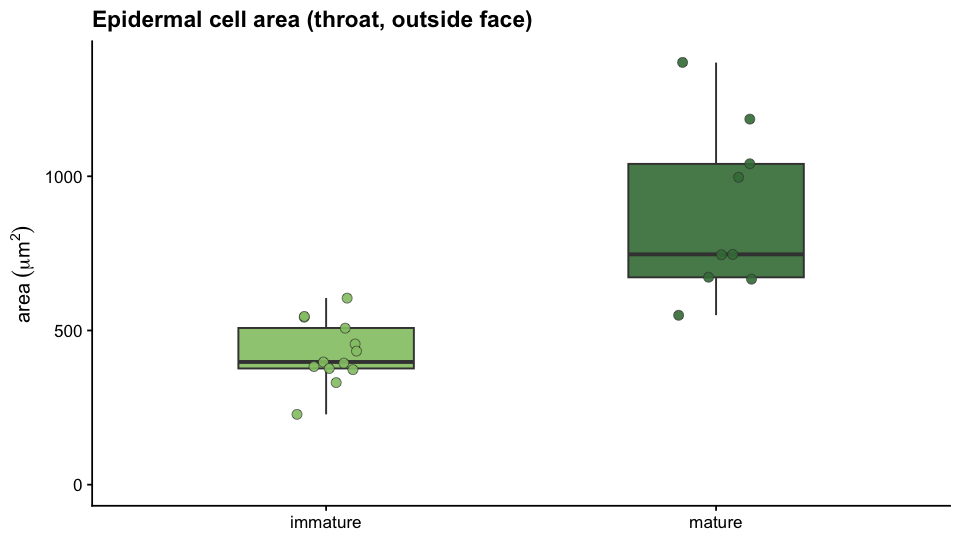

In [5]:
#### plot cell area ############################################################

plot1 <- ggplot(good_cells, aes(x = stage, y = area_um2, fill = stage)) +
  geom_boxplot(width = 0.45, outlier.shape = NA, alpha = 0.9, colour = outline) +
  geom_jitter(shape = 21, width = 0.10, size = 2.6, stroke = 0.3,
              colour = outline, alpha = 0.9) +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, NA)) +
  labs(title = "Epidermal cell area (throat, outside face)",
       x = NULL, y = expression(area~(mu*m^2))) +
  theme(legend.position = "none")

plot1
ggsave("output/cell_area.png", plot1, width = 6, height = 4.5, dpi = 300)

In [6]:
#### summary numbers ###########################################################

good_cells %>%
  group_by(stage) %>%
  summarise(
    n         = n(),
    mean_area = mean(area_um2),
    sd_area   = sd(area_um2),
    mean_diam = mean(diameter_um)
  ) -> summary_table

as.data.frame(summary_table)

stage,n,mean_area,sd_area,mean_diam
<fct>,<int>,<dbl>,<dbl>,<dbl>
immature,13,428.6948,101.9927,23.20220
mature,9,885.5666,274.9803,33.22965


In [7]:
#### is the difference real ####################################################

good_cells %>% filter(stage == "immature") %>% pull(area_um2) -> immature_cells
good_cells %>% filter(stage == "mature")   %>% pull(area_um2) -> mature_cells

wilcox.test(immature_cells, mature_cells)


	Wilcoxon rank sum exact test

data:  immature_cells and mature_cells
W = 1, p-value = 8.041e-06
alternative hypothesis: true location shift is not equal to 0
